# 22 — Gateway Decision Analysis: LSTM Surrogate vs Ground Truth

For each **decision point** (gateway) in the process, trains two decision trees
on identical prefixes:

1. **LSTM Surrogate** — target = model's predicted next activity
2. **Ground Truth** — target = actual next activity from the event log

Compares rules, feature importances, and agreement to reveal whether the LSTM
has learned the same decision logic that exists in the data.

In [13]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [ ]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'domestic_declarations_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

from src.interpretability.config.domestic_declarations_config import CONFIG
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- Feature indices ---
ACT_IDX = 0    # Activity
RES_IDX = 1    # Resource
ROLE_IDX = 2   # Role (event-level)

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')
day_num_idx = decoder.num_features.index('day_in_week')
amount_num_idx = decoder.num_features.index('Amount')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

## Build DFG and identify qualifying gateways

A gateway is an activity with more than one observed successor. We filter to
gateways with at least `MIN_CASES` prefixes and at least two branches with
`MIN_BRANCH` cases each, so the decision trees have enough data.

In [ ]:
MIN_CASES = 50       # minimum prefixes at this gateway
MIN_BRANCH = 10      # minimum cases per branch (need at least 2 branches above this)
MIN_SAMPLES_LEAF = 20

ACTIVITY_WINDOW = 40                # number of recent events to include as positional features
CASE_LEVEL_THRESHOLD = 0.95     # feature is case-level if it's constant within a case in >=95% of cases

# --- Collect unique cases (longest trace per case_id) ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'{len(cases)} unique cases')

# --- Data-driven classification: event-level vs case-level ---
# A feature is case-level if at least CASE_LEVEL_THRESHOLD of cases have a single
# constant value across all real (non-EOS) events of the case.
_n_cat_const = [0] * n_cat
_n_num_const = [0] * n_num
_total_checked = 0
for _cid, (_idx, _L) in cases.items():
    _cat_t, _num_t, _ = dataset[_idx]
    _s = seq_len - _L
    _useful = _L
    for _j in range(_L - 1, -1, -1):
        if _cat_t[ACT_IDX][_s + _j].item() == eos_idx:
            _useful = _j
        else:
            break
    if _useful == 0:
        continue
    _total_checked += 1
    for _ci in range(n_cat):
        _vals = _cat_t[_ci][_s:_s + _useful].tolist()
        if len(set(_vals)) == 1:
            _n_cat_const[_ci] += 1
    for _ni in range(n_num):
        _vals = _num_t[_ni][_s:_s + _useful].tolist()
        if max(_vals) - min(_vals) < 1e-6:
            _n_num_const[_ni] += 1

EVENT_CAT_INDICES = [i for i in range(n_cat)
                     if _n_cat_const[i] / _total_checked < CASE_LEVEL_THRESHOLD]
EVENT_NUM_INDICES = [i for i in range(n_num)
                     if _n_num_const[i] / _total_checked < CASE_LEVEL_THRESHOLD]

print(f'\nFeature classification (threshold: {CASE_LEVEL_THRESHOLD:.0%} constant -> case-level, '
      f'based on {_total_checked} cases):')
for _ci in range(n_cat):
    _pct = _n_cat_const[_ci] / _total_checked
    _tag = 'event-level' if _ci in EVENT_CAT_INDICES else 'CASE-LEVEL'
    print(f'  cat[{_ci}] {decoder.cat_features[_ci]:35s} {_pct:5.1%} constant  -> {_tag}')
for _ni in range(n_num):
    _pct = _n_num_const[_ni] / _total_checked
    _tag = 'event-level' if _ni in EVENT_NUM_INDICES else 'CASE-LEVEL'
    print(f'  num[{_ni}] {decoder.num_features[_ni]:35s} {_pct:5.1%} constant  -> {_tag}')

# --- Build DFG ---
dfg = {}
successors_map = {}

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'\nDecision points ({len(decision_points)}):')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c}, {c/total*100:.0f}%)' for s, c in
                         sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total} cases): {branches}')

## Collect per-gateway prefixes

For each qualifying gateway, find every prefix that ends at that activity (where
a real next activity exists). Extract both the actual next activity and the
LSTM's prediction, plus engineered features for the surrogate trees.

In [ ]:
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract features for a single prefix.

    Kept minimal: prefix_length, case-level features (cat + num) at the gateway
    position, and positional encoding over the last ACTIVITY_WINDOW events for
    every event-level categorical AND numerical feature.
    """
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    feats = {'prefix_length': prefix_len}

    # Case-level categorical features (event-level ones are covered by positional features below)
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci in EVENT_CAT_INDICES:
            continue
        val = cat_tuple[ci][end - 1].item()
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, val))

    # Case-level numerical features (event-level ones are covered by positional features below)
    for ni, feat_name in enumerate(decoder.num_features):
        if ni in EVENT_NUM_INDICES:
            continue
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(
            feat_name, num_tuple[ni][end - 1].item())

    # Positional features for every event-level categorical feature (last ACTIVITY_WINDOW events)
    for ci in EVENT_CAT_INDICES:
        feat_name = decoder.cat_features[ci]
        tensor = cat_tuple[ci][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_categorical_value(ci, tensor[pos].item())
            else:
                feats[key] = '<pad>'

    # Positional features for every event-level numerical feature (last ACTIVITY_WINDOW events)
    for ni in EVENT_NUM_INDICES:
        feat_name = decoder.num_features[ni]
        tensor = num_tuple[ni][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_numerical_value(feat_name, tensor[pos].item())
            else:
                feats[key] = float('nan')

    return feats


# --- Collect gateway data ---
gateway_data = {}  # gateway_name -> {X, y_lstm, y_actual, cat_list, num_list}

for gateway_act, succs in decision_points.items():
    # Check if gateway qualifies
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows = []
    actual_labels = []
    cat_list = []
    num_list = []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        # Strip trailing EOS
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        # Find all positions where activity == gateway and next activity exists
        for k in range(useful_len - 1):
            act_idx_val = acts[k].item()
            if activity_names[act_idx_val] != gateway_act:
                continue

            next_act_name = activity_names[acts[k + 1].item()]
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            # Build padded prefix tensors
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    # Batch-predict LSTM labels
    N = len(X)
    cat_batch = [
        torch.stack([cat_list[i][ci] for i in range(N)])
        for ci in range(n_cat)
    ]
    num_stacked = torch.stack([
        torch.stack(num_list[i], dim=-1) for i in range(N)
    ])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
    }

    # Report
    n_branches_actual = len(set(y_actual))
    n_branches_lstm = len(set(y_lstm))
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'\n{gateway_act}: {N} prefixes, '
          f'{n_branches_actual} actual branches, {n_branches_lstm} LSTM branches, '
          f'LSTM accuracy={lstm_acc:.3f}')
    print(f'  Actual distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_actual, return_counts=True))))
    print(f'  LSTM   distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_lstm, return_counts=True))))

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')

## Train surrogate and ground truth trees per gateway

For each gateway, the same 80/20 stratified split is used for both trees so
they are compared on identical test sets. Depth is swept and the shallowest
tree within 2% of the best fidelity is selected.

In [ ]:
def decode_tree_text(text, cat_cols, cat_mappings):
    """Replace ordinal split thresholds with actual category names."""
    decoded = []
    for line in text.split('\n'):
        out = line
        for col in cat_cols:
            pattern = rf'({re.escape(col)})\s*(<=|>)\s*([\d.]+)'
            m = re.search(pattern, line)
            if m:
                feat, op, thresh = m.group(1), m.group(2), float(m.group(3))
                cats = cat_mappings[feat]
                if op == '<=':
                    incl = [c for i, c in enumerate(cats) if i <= thresh]
                else:
                    incl = [c for i, c in enumerate(cats) if i > thresh]
                if len(incl) <= 8:
                    out += f'  [{feat} in {{{", ".join(str(c) for c in incl)}}}]'
                else:
                    out += f'  [{feat} in {{{", ".join(str(c) for c in incl[:6])}, ... ({len(incl)} total)}}]'
                break
        decoded.append(out)
    return '\n'.join(decoded)


def select_best_depth(X_train, y_train, X_test, y_test, depths=(3, 4, 5, 6, 7, 8)):
    """Sweep depths; prefer shallowest within 2% of best test score."""
    results = []
    for depth in depths:
        clf = DecisionTreeClassifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        train_sc = clf.score(X_train, y_train)
        test_sc = clf.score(X_test, y_test)
        results.append({'depth': depth, 'train': train_sc, 'test': test_sc, 'clf': clf})

    best_idx = 0
    best_test = results[0]['test']
    for i in range(1, len(results)):
        if results[i]['test'] > best_test + 0.02:
            best_idx = i
            best_test = results[i]['test']
    return results[best_idx]['clf'], results


# --- Train trees for each gateway ---
gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    # Identify column types
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    num_cols = [c for c in X.columns if c not in cat_cols]

    # Ordinal-encode categoricals
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_enc = X.copy()
    X_enc[cat_cols] = ord_enc.fit_transform(X[cat_cols].astype(str))

    cat_mappings = {}
    for i, col in enumerate(cat_cols):
        cat_mappings[col] = list(ord_enc.categories_[i])

    # Stratified split (stratify on actual labels for consistent branch coverage)
    # Use y_actual for stratification since it has the real distribution
    try:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        # Stratification fails if a class has < 2 members; fall back
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2, random_state=42)

    feature_names = list(X_enc.columns)

    # Train LSTM surrogate tree
    clf_lstm, lstm_sweep = select_best_depth(X_train, y_lstm_train, X_test, y_lstm_test)
    # Train ground truth tree
    clf_gt, gt_sweep = select_best_depth(X_train, y_actual_train, X_test, y_actual_test)

    # Metrics
    surrogate_fidelity = clf_lstm.score(X_test, y_lstm_test)
    gt_accuracy = clf_gt.score(X_test, y_actual_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()
    agreement = (clf_lstm.predict(X_test) == clf_gt.predict(X_test)).mean()

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'cat_cols': cat_cols, 'cat_mappings': cat_mappings,
        'ord_enc': ord_enc,
        'X_train': X_train, 'X_test': X_test,
        'y_lstm_train': y_lstm_train, 'y_lstm_test': y_lstm_test,
        'y_actual_train': y_actual_train, 'y_actual_test': y_actual_test,
        'surrogate_fidelity': surrogate_fidelity,
        'gt_accuracy': gt_accuracy,
        'lstm_accuracy': lstm_accuracy,
        'agreement': agreement,
        'n_cases': len(X),
        'lstm_sweep': lstm_sweep, 'gt_sweep': gt_sweep,
    }

    print(f'\n{"=" * 70}')
    print(f'Gateway: {gateway_act} ({len(X)} prefixes)')
    print(f'  LSTM accuracy at gateway:     {lstm_accuracy:.3f}')
    print(f'  Surrogate fidelity (vs LSTM): {surrogate_fidelity:.3f}  '
          f'(depth={clf_lstm.get_depth()}, leaves={clf_lstm.get_n_leaves()})')
    print(f'  Ground truth tree accuracy:   {gt_accuracy:.3f}  '
          f'(depth={clf_gt.get_depth()}, leaves={clf_gt.get_n_leaves()})')
    print(f'  Agreement (surrogate vs GT):  {agreement:.3f}')


Gateway: SUBMITTED (2295 prefixes)
  LSTM accuracy at gateway:     0.778
  Surrogate fidelity (vs LSTM): 0.991  (depth=1, leaves=2)
  Ground truth tree accuracy:   0.580  (depth=4, leaves=11)
  Agreement (surrogate vs GT):  0.593

Gateway: APPROVED (2370 prefixes)
  LSTM accuracy at gateway:     0.719
  Surrogate fidelity (vs LSTM): 0.992  (depth=2, leaves=3)
  Ground truth tree accuracy:   0.532  (depth=3, leaves=6)
  Agreement (surrogate vs GT):  0.295

Gateway: FINAL_APPROVED (2019 prefixes)
  LSTM accuracy at gateway:     0.990
  Surrogate fidelity (vs LSTM): 1.000  (depth=0, leaves=1)
  Ground truth tree accuracy:   0.889  (depth=7, leaves=16)
  Agreement (surrogate vs GT):  0.894

Gateway: REJECTED (489 prefixes)
  LSTM accuracy at gateway:     0.041
  Surrogate fidelity (vs LSTM): 0.786  (depth=3, leaves=5)
  Ground truth tree accuracy:   0.969  (depth=3, leaves=5)
  Agreement (surrogate vs GT):  0.092


## Summary table

In [18]:
summary_rows = []
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_
    top_lstm = fn[np.argmax(imp_lstm)]
    top_gt = fn[np.argmax(imp_gt)]

    summary_rows.append({
        'Gateway': gateway_act,
        '#Cases': gr['n_cases'],
        '#Branches (actual)': len(set(gr['y_actual_train']) | set(gr['y_actual_test'])),
        'LSTM Accuracy': f'{gr["lstm_accuracy"]:.3f}',
        'Surrogate Fidelity': f'{gr["surrogate_fidelity"]:.3f}',
        'GT Tree Accuracy': f'{gr["gt_accuracy"]:.3f}',
        'Agreement': f'{gr["agreement"]:.3f}',
        'Top LSTM Feature': top_lstm,
        'Top GT Feature': top_gt,
        'Same Top Feature': top_lstm == top_gt,
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Gateway,#Cases,#Branches (actual),LSTM Accuracy,Surrogate Fidelity,GT Tree Accuracy,Agreement,Top LSTM Feature,Top GT Feature,Same Top Feature
0,SUBMITTED,2295,3,0.778,0.991,0.580,0.593,total_elapsed_time,last_Amount,False
1,APPROVED,2370,3,0.719,0.992,0.532,0.295,mean_event_duration,Role_pos_-1,False
2,FINAL_APPROVED,2019,3,0.990,1.000,0.889,0.894,prefix_length,Role_pos_-2,False
3,REJECTED,489,2,0.041,0.786,0.969,0.092,mean_event_duration,last_activity_repeated,False


## Feature importance comparison

Side-by-side bar charts: which features does the LSTM surrogate rely on vs
which features explain the actual process decisions?

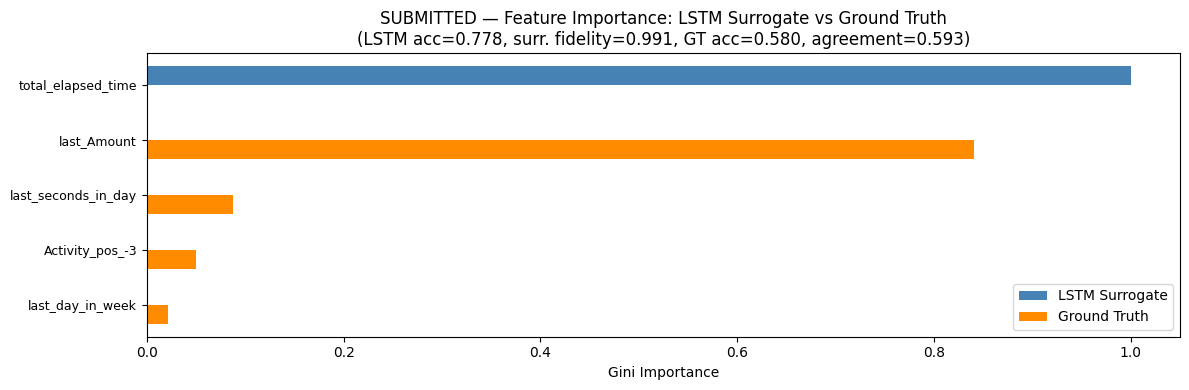

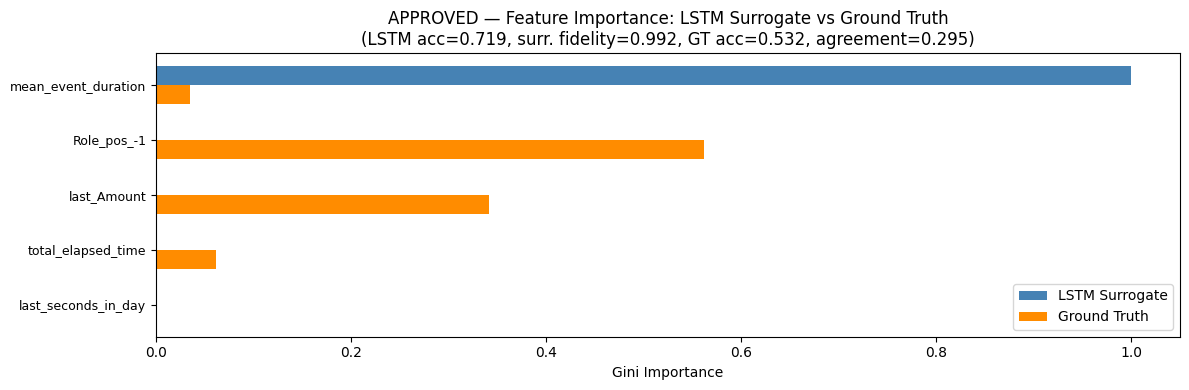

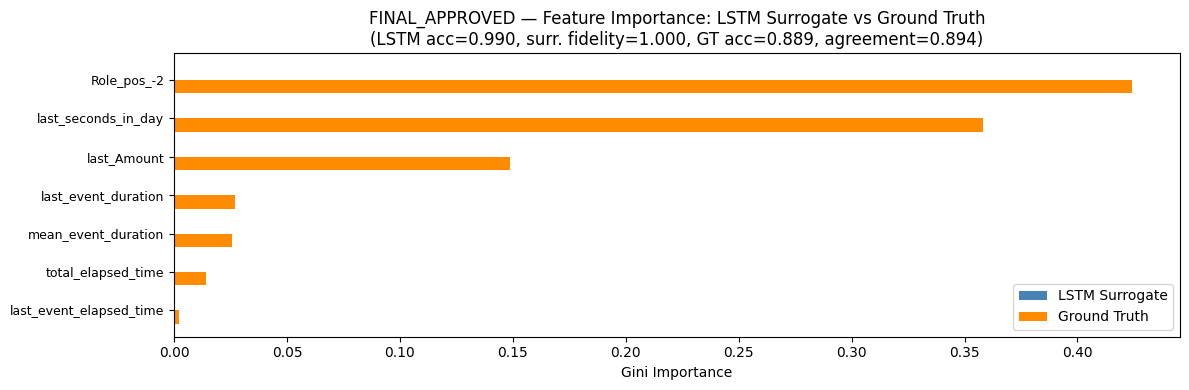

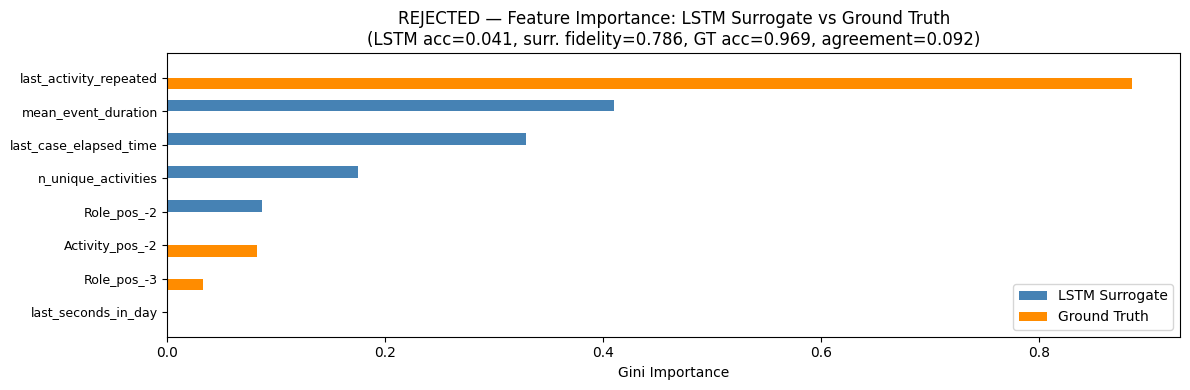

In [19]:
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_

    # Only show features with non-zero importance in either tree
    mask = (imp_lstm > 0) | (imp_gt > 0)
    fn_nz = [f for f, m in zip(fn, mask) if m]
    imp_lstm_nz = imp_lstm[mask]
    imp_gt_nz = imp_gt[mask]

    # Sort by max importance across both
    order = np.argsort(np.maximum(imp_lstm_nz, imp_gt_nz))[::-1]
    fn_nz = [fn_nz[i] for i in order]
    imp_lstm_nz = imp_lstm_nz[order]
    imp_gt_nz = imp_gt_nz[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(fn_nz) * 0.4)))
    y_pos = np.arange(len(fn_nz))
    bar_h = 0.35

    ax.barh(y_pos - bar_h / 2, imp_lstm_nz, bar_h, label='LSTM Surrogate', color='steelblue')
    ax.barh(y_pos + bar_h / 2, imp_gt_nz, bar_h, label='Ground Truth', color='darkorange')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_nz, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Gini Importance')
    ax.set_title(f'{gateway_act} — Feature Importance: LSTM Surrogate vs Ground Truth\n'
                 f'(LSTM acc={gr["lstm_accuracy"]:.3f}, '
                 f'surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
                 f'GT acc={gr["gt_accuracy"]:.3f}, '
                 f'agreement={gr["agreement"]:.3f})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Side-by-side tree visualizations

Trees are capped at **depth 4** for readability. Full decision logic is in the
if/then rules section below. Split conditions show decoded category names.

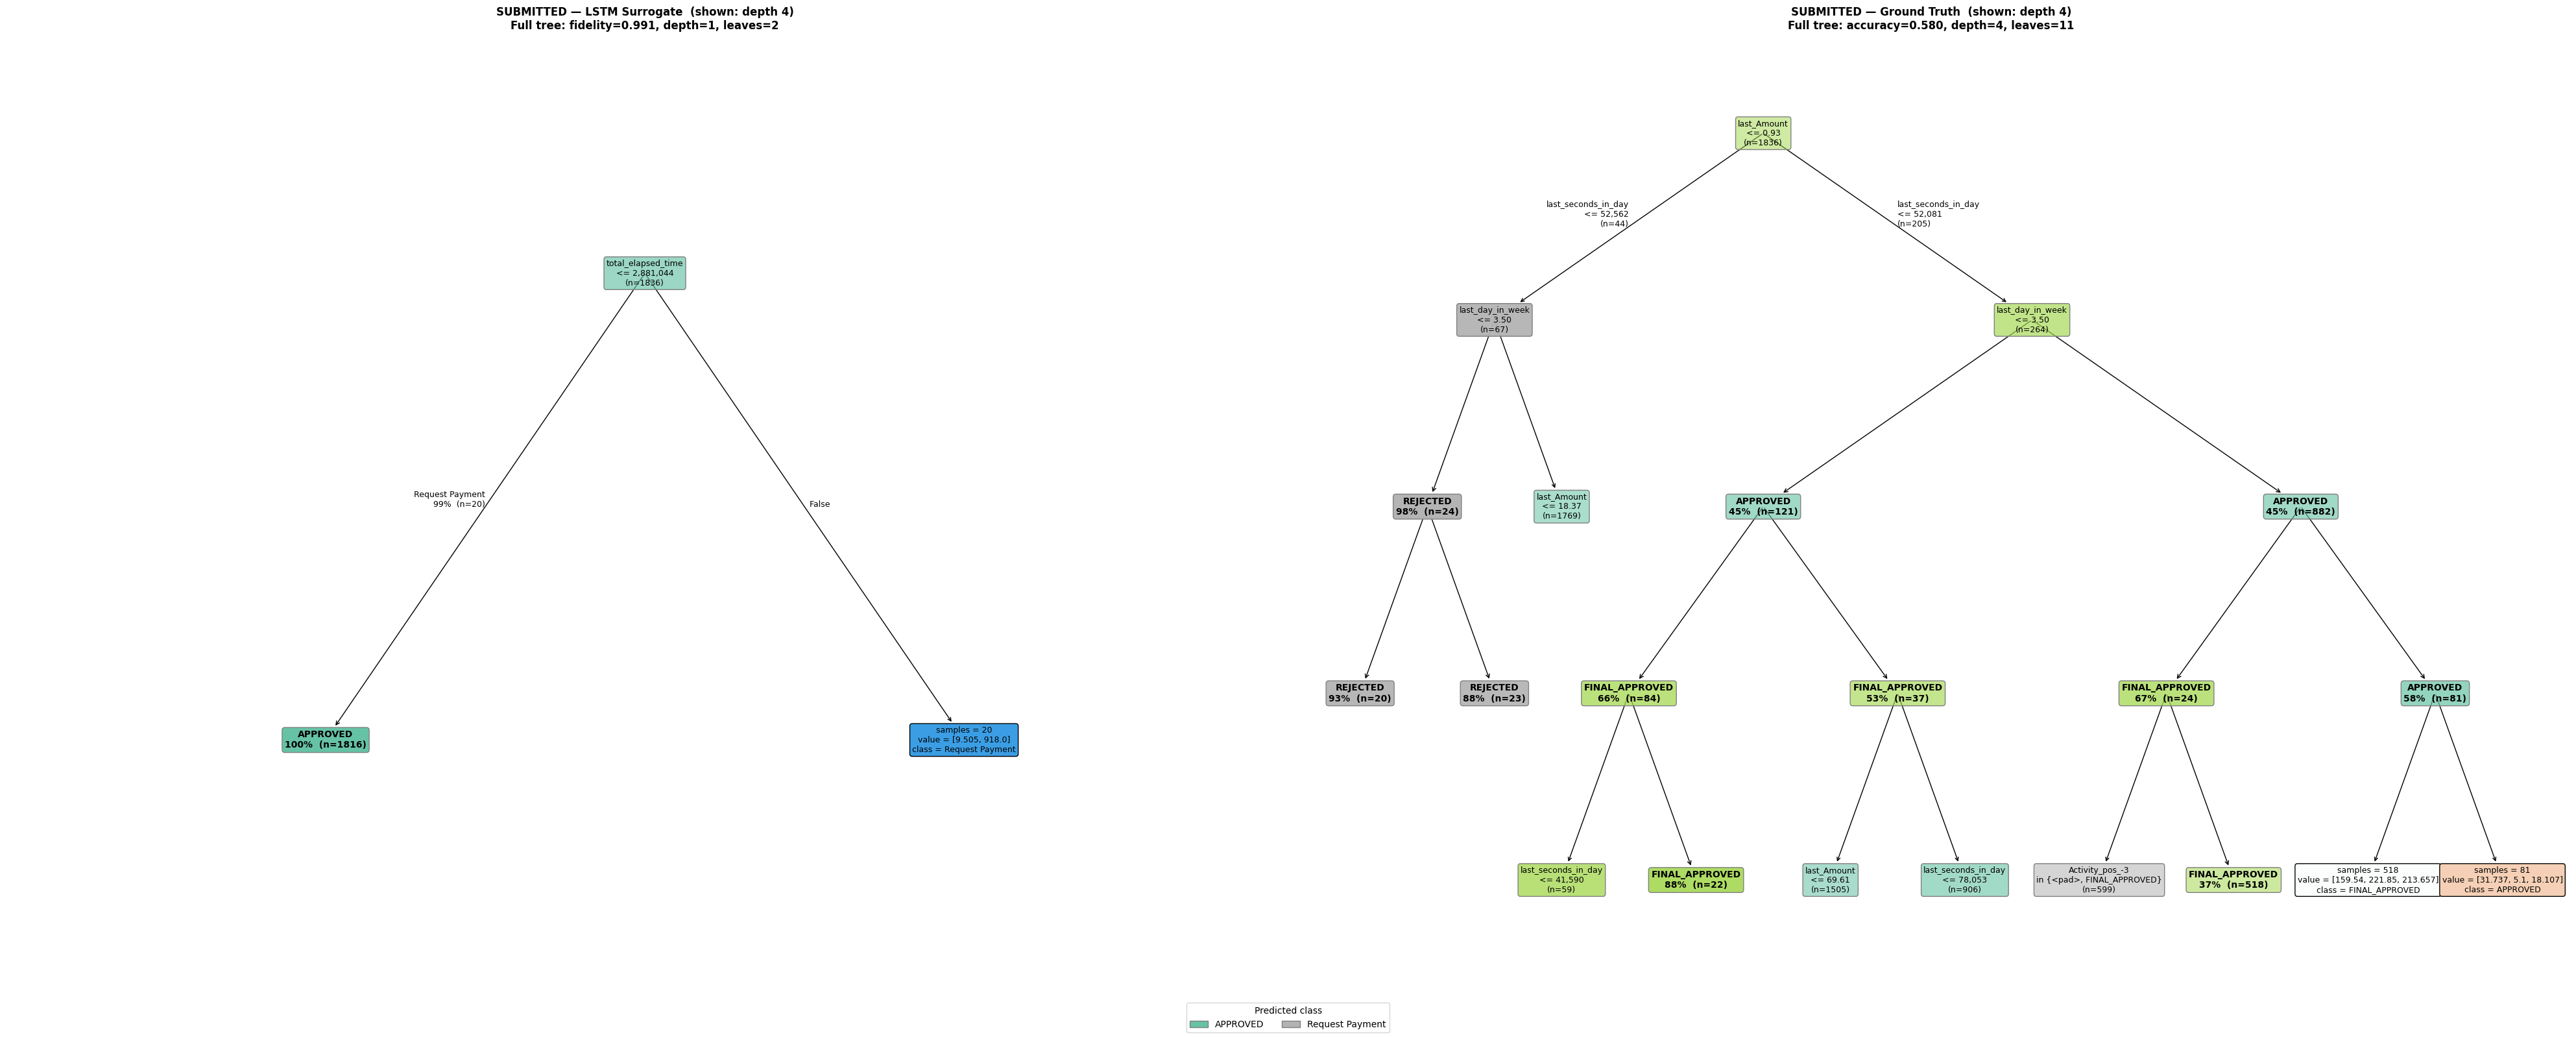

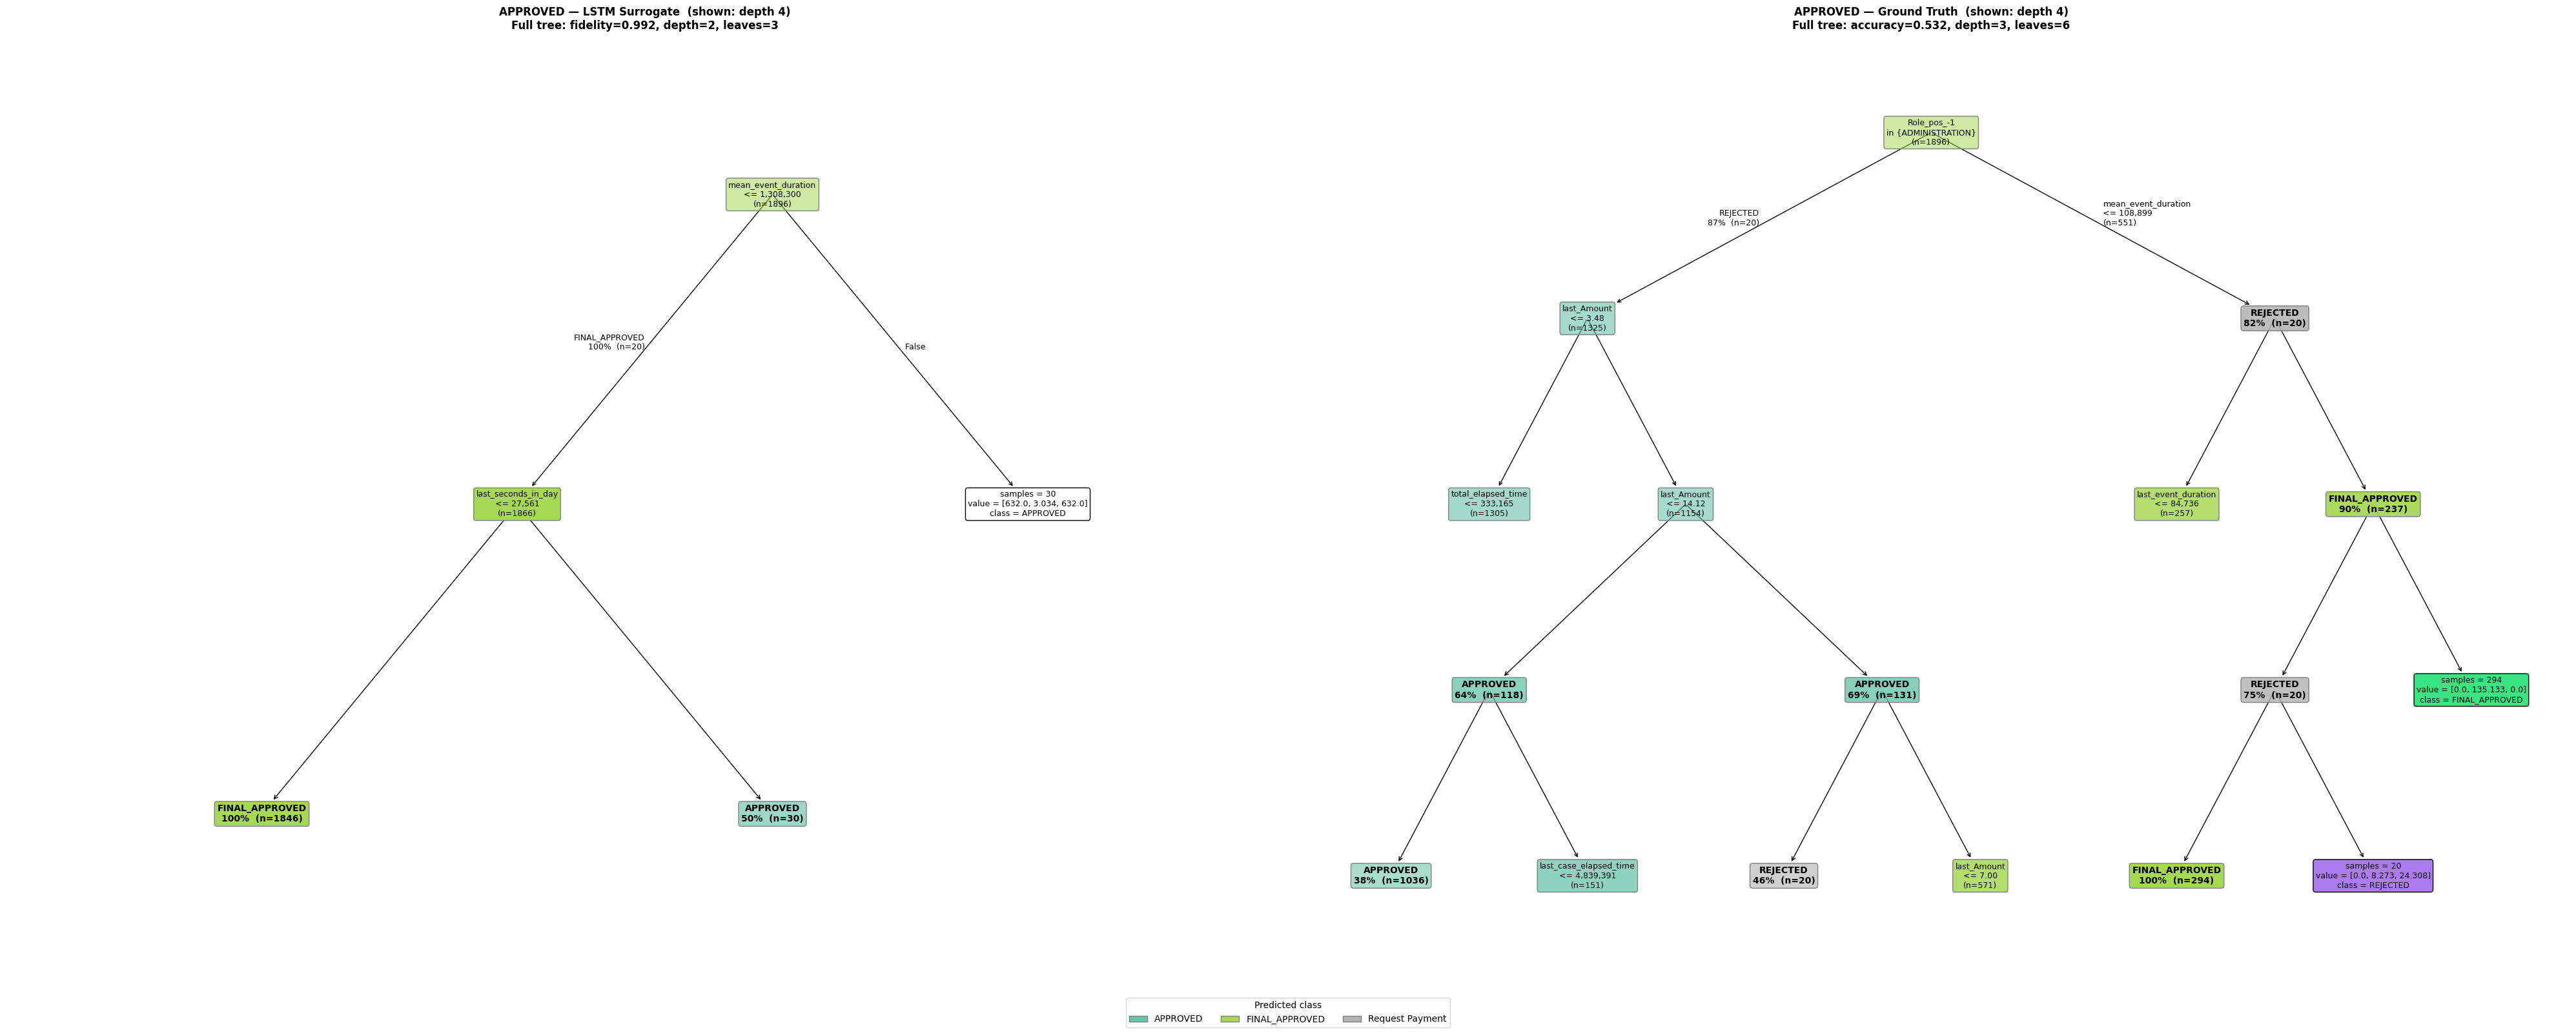

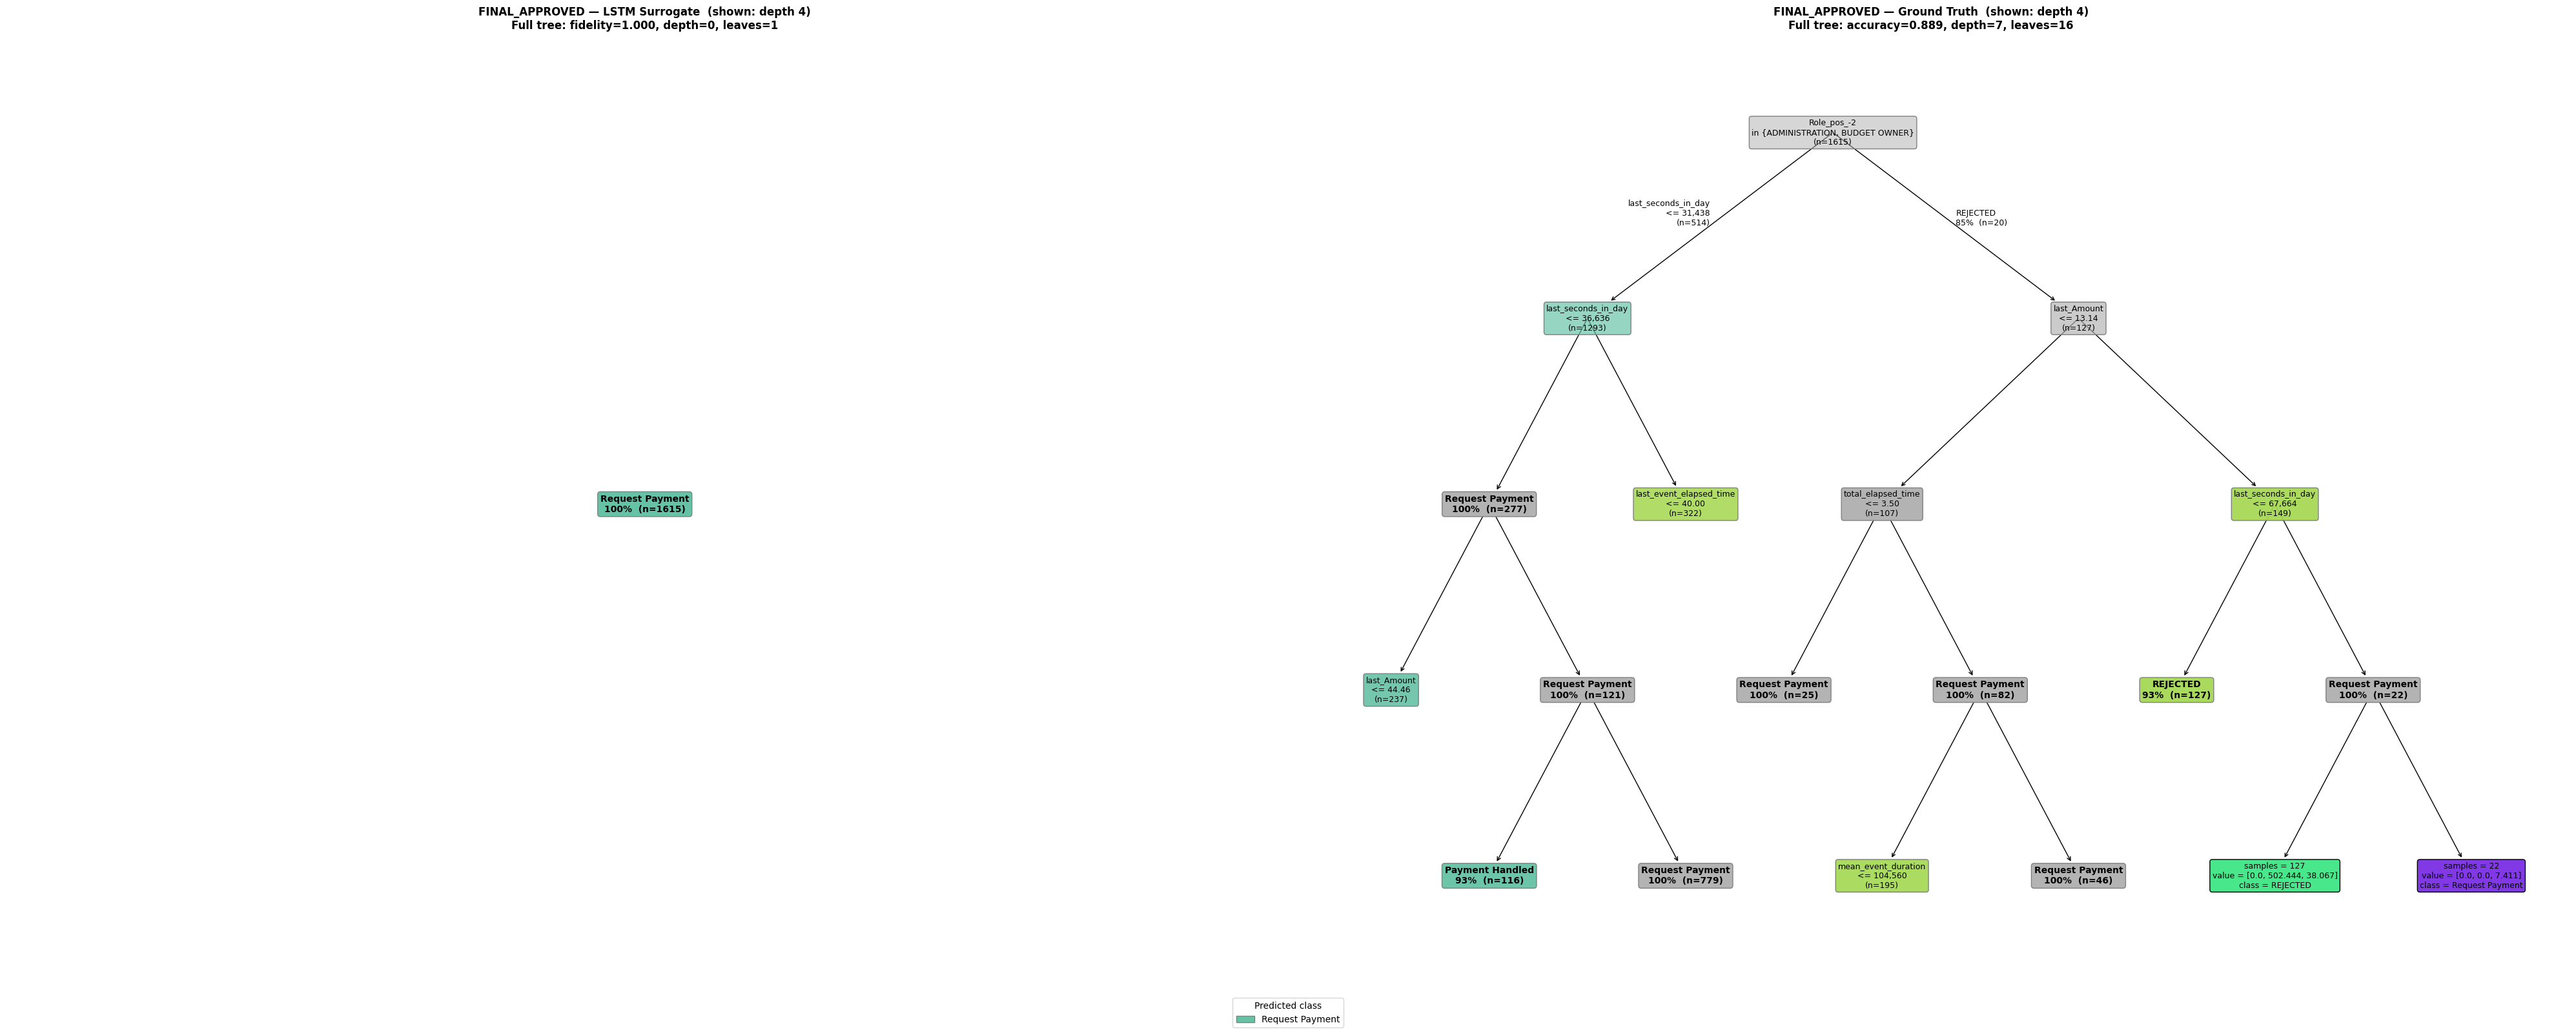

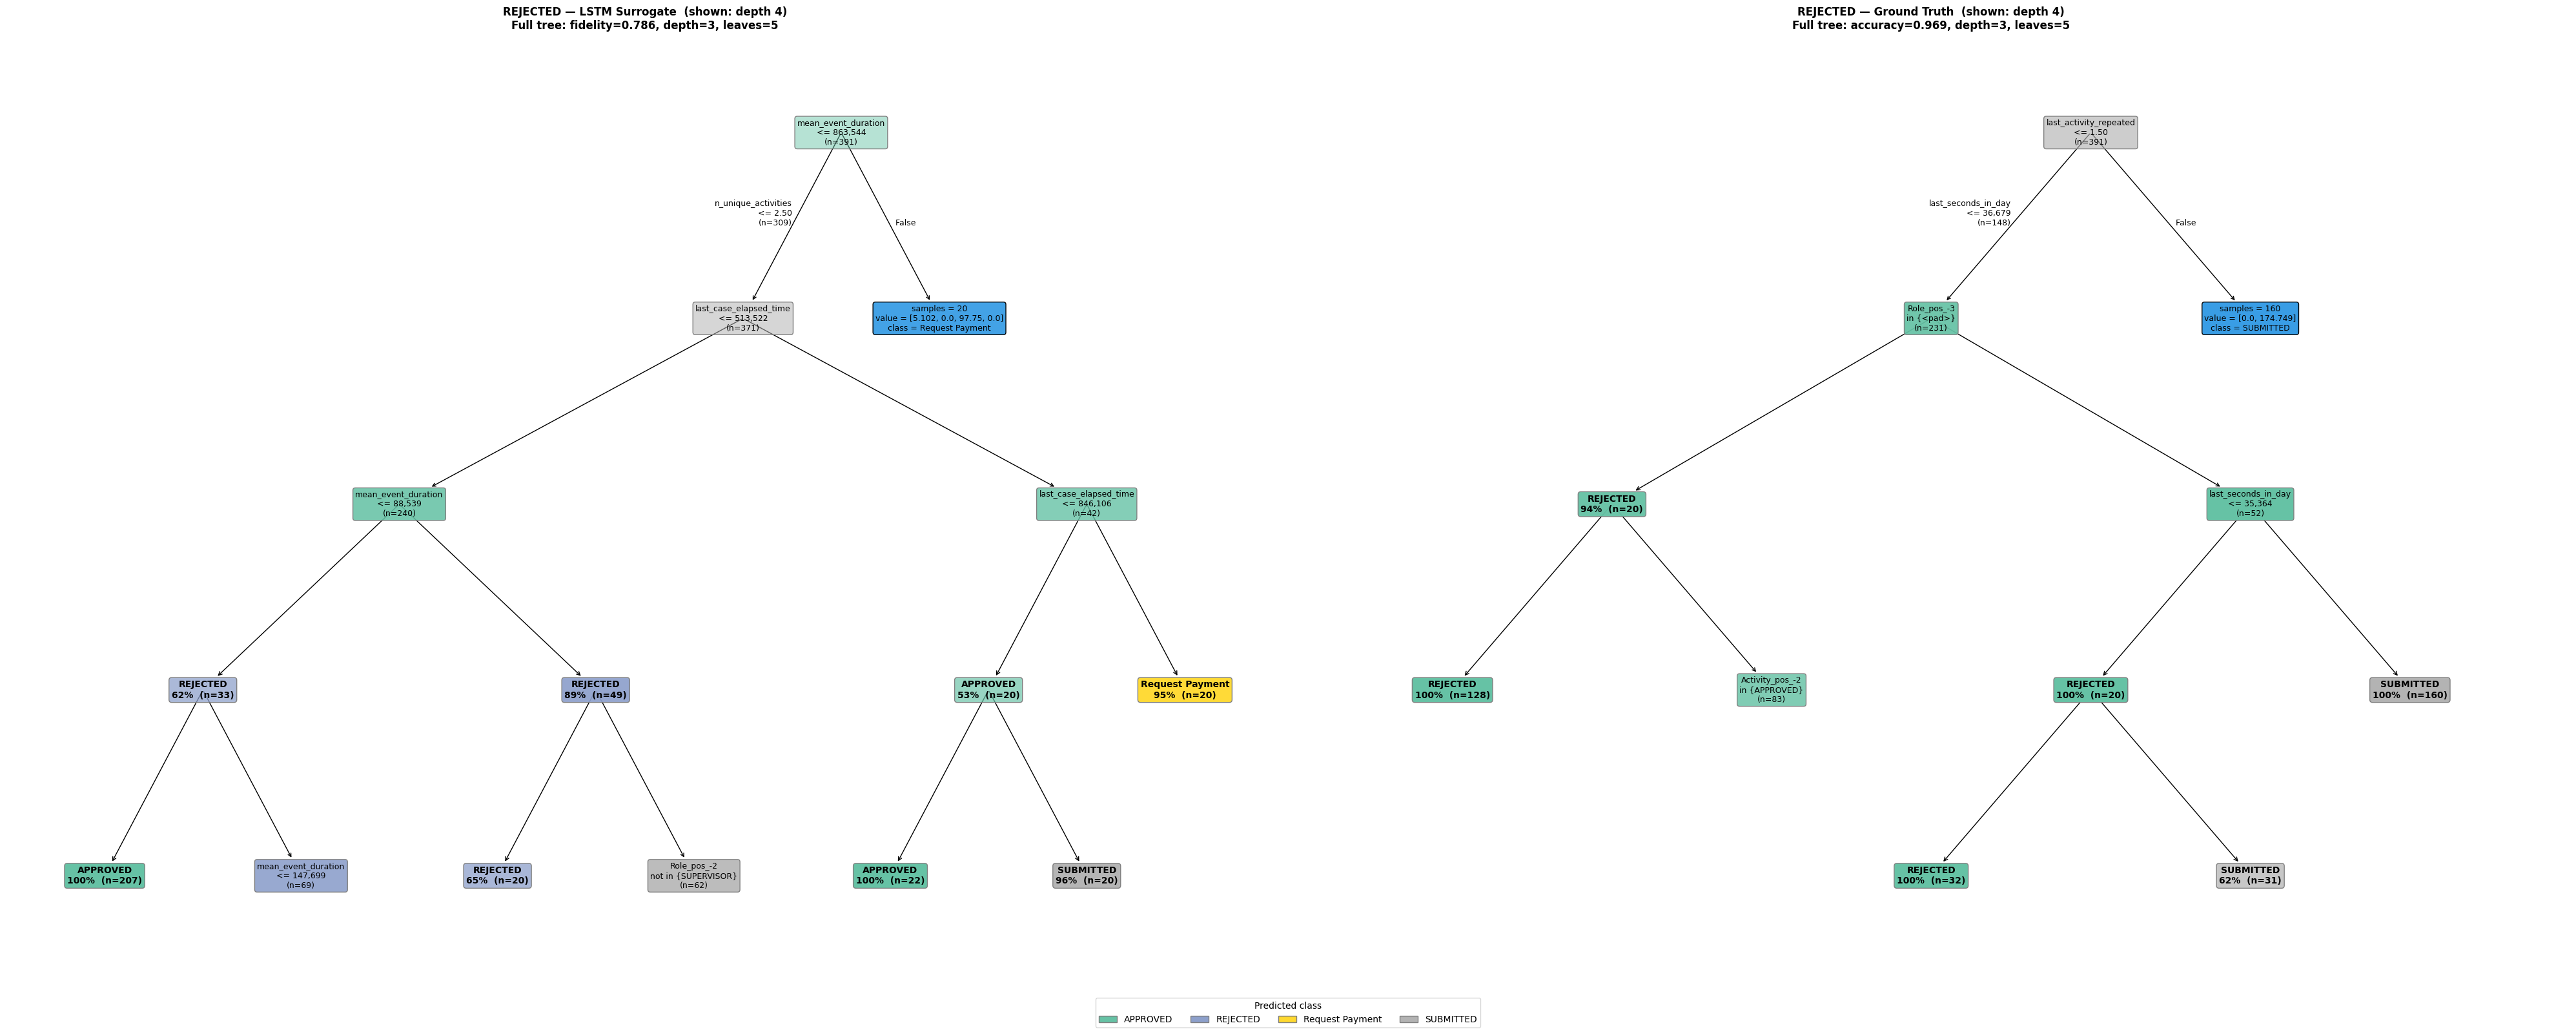

In [20]:
from sklearn.tree import _tree

VIS_MAX_DEPTH = 4  # cap tree depth for readable plots


def decode_split_label(feat_name, threshold, cat_cols, cat_mappings):
    """Turn 'feat <= 5.50' into readable category set or rounded number."""
    if feat_name in cat_cols:
        cats = cat_mappings[feat_name]
        left = [str(c) for i, c in enumerate(cats) if i <= threshold]
        right = [str(c) for i, c in enumerate(cats) if i > threshold]
        if len(left) <= len(right) and len(left) <= 5:
            return f'{feat_name}\nin {{{", ".join(left)}}}'
        elif len(right) <= 5:
            return f'{feat_name}\nnot in {{{", ".join(right)}}}'
        elif len(left) <= 8:
            return f'{feat_name}\nin {{{", ".join(left)}}}'
        else:
            return f'{feat_name}\nin {{{", ".join(left[:4])},\n... +{len(left)-4} more}}'
    else:
        if abs(threshold) > 10000:
            return f'{feat_name}\n<= {threshold:,.0f}'
        else:
            return f'{feat_name}\n<= {threshold:.2f}'


def build_node_labels(clf, feature_names, cat_cols, cat_mappings):
    """Build decoded label for every node in the tree."""
    tree = clf.tree_
    class_names = clf.classes_
    labels = []

    for node_id in range(tree.node_count):
        n_samples = int(tree.n_node_samples[node_id])
        values = tree.value[node_id].flatten()
        majority_idx = np.argmax(values)
        majority_class = class_names[majority_idx]
        confidence = values[majority_idx] / values.sum()

        if tree.feature[node_id] == _tree.TREE_UNDEFINED:
            labels.append(f'{majority_class}\n{confidence:.0%}  (n={n_samples})')
        else:
            feat_idx = tree.feature[node_id]
            feat_name = feature_names[feat_idx]
            threshold = tree.threshold[node_id]
            split_text = decode_split_label(feat_name, threshold, cat_cols, cat_mappings)
            labels.append(f'{split_text}\n(n={n_samples})')

    return labels


def get_class_color_map(class_names):
    """Assign a distinct color to each class."""
    cmap = plt.colormaps.get_cmap('Set2').resampled(len(class_names))
    return {name: cmap(i) for i, name in enumerate(class_names)}


def draw_decoded_tree(clf_full, X_train, y_train, feature_names, cat_cols,
                      cat_mappings, ax, title):
    """Draw a shallow tree with decoded labels for readability."""
    clf_vis = DecisionTreeClassifier(
        max_depth=VIS_MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF,
        class_weight='balanced', random_state=42)
    clf_vis.fit(X_train, y_train)

    tree = clf_vis.tree_
    class_names = clf_vis.classes_
    color_map = get_class_color_map(class_names)
    labels = build_node_labels(clf_vis, feature_names, cat_cols, cat_mappings)

    artists = plot_tree(clf_vis, feature_names=feature_names,
                        class_names=class_names.tolist(),
                        filled=True, rounded=True, ax=ax, fontsize=1,
                        impurity=False, proportion=False)

    # Update node labels
    for i, artist in enumerate(artists):
        if i >= len(labels):
            continue
        artist.set_text(labels[i])

        bbox = artist.get_bbox_patch()
        if bbox is None:
            continue

        values = tree.value[i].flatten()
        majority_idx = np.argmax(values)
        majority_class = class_names[majority_idx]
        confidence = values[majority_idx] / values.sum()

        color = color_map[majority_class]
        alpha = 0.3 + 0.7 * confidence
        bbox.set_facecolor((*color[:3], alpha))
        bbox.set_edgecolor('gray')
        bbox.set_linewidth(1.0)

        is_leaf = tree.feature[i] == _tree.TREE_UNDEFINED
        if is_leaf:
            artist.set_fontsize(10)
            artist.set_fontweight('bold')
        else:
            artist.set_fontsize(9)

    # Bump up ALL text on the axes (catches edge labels like "True"/"False"
    # and any other annotations that plot_tree added outside the node artists)
    for txt in ax.texts:
        if txt.get_fontsize() < 9:
            txt.set_fontsize(9)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)


# --- Draw for each gateway ---
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    cc = gr['cat_cols']
    cm_map = gr['cat_mappings']

    fig, axes = plt.subplots(1, 2, figsize=(40, 16))

    draw_decoded_tree(
        gr['clf_lstm'], gr['X_train'], gr['y_lstm_train'],
        fn, cc, cm_map, axes[0],
        f'{gateway_act} — LSTM Surrogate  (shown: depth {VIS_MAX_DEPTH})\n'
        f'Full tree: fidelity={gr["surrogate_fidelity"]:.3f}, '
        f'depth={gr["clf_lstm"].get_depth()}, leaves={gr["clf_lstm"].get_n_leaves()}')

    draw_decoded_tree(
        gr['clf_gt'], gr['X_train'], gr['y_actual_train'],
        fn, cc, cm_map, axes[1],
        f'{gateway_act} — Ground Truth  (shown: depth {VIS_MAX_DEPTH})\n'
        f'Full tree: accuracy={gr["gt_accuracy"]:.3f}, '
        f'depth={gr["clf_gt"].get_depth()}, leaves={gr["clf_gt"].get_n_leaves()}')

    all_classes = sorted(set(gr['clf_lstm'].classes_) | set(gr['clf_gt'].classes_))
    color_map = get_class_color_map(gr['clf_lstm'].classes_)
    legend_patches = [plt.Rectangle((0, 0), 1, 1, fc=color_map.get(c, 'lightgray'),
                                     ec='gray', label=c)
                      for c in all_classes if c in color_map]
    fig.legend(handles=legend_patches, loc='lower center', ncol=len(legend_patches),
               fontsize=10, frameon=True, title='Predicted class')

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

## Decision rules as readable if/then statements

Each leaf becomes one rule. Conditions along the path from root to leaf are
combined with AND. Rules are sorted by sample count (most common decisions
first).

In [21]:
def decode_condition(feat_name, threshold, direction, cat_cols, cat_mappings):
    """Single split condition as readable text."""
    if feat_name in cat_cols:
        cats = cat_mappings[feat_name]
        if direction == '<=':
            incl = [str(c) for i, c in enumerate(cats) if i <= threshold]
        else:
            incl = [str(c) for i, c in enumerate(cats) if i > threshold]
        if len(incl) <= 5:
            return f'{feat_name} in {{{", ".join(incl)}}}'
        else:
            return f'{feat_name} in {{{", ".join(incl[:4])}, ... +{len(incl)-4} more}}'
    else:
        if abs(threshold) > 10000:
            return f'{feat_name} {"<=" if direction == "<=" else ">"} {threshold:,.0f}'
        else:
            return f'{feat_name} {"<=" if direction == "<=" else ">"} {threshold:.2f}'


def extract_rules(clf, feature_names, cat_cols, cat_mappings):
    """Extract all root-to-leaf paths as readable rules."""
    tree = clf.tree_
    class_names = clf.classes_
    rules = []

    def recurse(node_id, conditions):
        if tree.feature[node_id] == _tree.TREE_UNDEFINED:
            # Leaf
            values = tree.value[node_id].flatten()
            majority_idx = np.argmax(values)
            n_samples = int(tree.n_node_samples[node_id])
            confidence = values[majority_idx] / values.sum()
            rules.append({
                'conditions': list(conditions),
                'prediction': class_names[majority_idx],
                'confidence': confidence,
                'n_samples': n_samples,
            })
            return

        feat_idx = tree.feature[node_id]
        feat_name = feature_names[feat_idx]
        threshold = tree.threshold[node_id]

        # Left child: <=
        cond_left = decode_condition(feat_name, threshold, '<=', cat_cols, cat_mappings)
        recurse(tree.children_left[node_id], conditions + [cond_left])

        # Right child: >
        cond_right = decode_condition(feat_name, threshold, '>', cat_cols, cat_mappings)
        recurse(tree.children_right[node_id], conditions + [cond_right])

    recurse(0, [])
    # Sort by sample count descending
    rules.sort(key=lambda r: -r['n_samples'])
    return rules


def print_rules(rules, label, max_rules=15):
    """Print rules in a compact if/then format."""
    print(f'\n  {label} ({len(rules)} rules, showing top {min(max_rules, len(rules))}):')
    print(f'  {"─" * 70}')
    for i, rule in enumerate(rules[:max_rules]):
        conds = '\n      AND '.join(rule['conditions'])
        print(f'  Rule {i+1} (n={rule["n_samples"]}, {rule["confidence"]:.0%} confidence):')
        print(f'    IF  {conds}')
        print(f'    THEN → {rule["prediction"]}')
        print()


for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    cc = gr['cat_cols']
    cm = gr['cat_mappings']

    print(f'{"=" * 80}')
    print(f'GATEWAY: {gateway_act}')

    rules_lstm = extract_rules(gr['clf_lstm'], fn, cc, cm)
    print_rules(rules_lstm, 'LSTM Surrogate')

    rules_gt = extract_rules(gr['clf_gt'], fn, cc, cm)
    print_rules(rules_gt, 'Ground Truth')

GATEWAY: SUBMITTED

  LSTM Surrogate (2 rules, showing top 2):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=1816, 100% confidence):
    IF  total_elapsed_time <= 2,881,044
    THEN → APPROVED

  Rule 2 (n=20, 99% confidence):
    IF  total_elapsed_time > 2,881,044
    THEN → Request Payment


  Ground Truth (11 rules, showing top 11):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=882, 45% confidence):
    IF  last_Amount > 0.93
      AND last_Amount > 18.37
      AND last_Amount <= 69.61
      AND last_seconds_in_day <= 78,053
    THEN → APPROVED

  Rule 2 (n=518, 37% confidence):
    IF  last_Amount > 0.93
      AND last_Amount > 18.37
      AND last_Amount > 69.61
      AND Activity_pos_-3 in {<pad>, FINAL_APPROVED}
    THEN → FINAL_APPROVED

  Rule 3 (n=121, 45% confidence):
    IF  last_Amount > 0.93
      AND last_Amount <= 18.37
      AND last_day_in_week <= 3.50
      AND last_seconds_in_day <= 52,081

## Confusion: surrogate predictions vs ground truth predictions

Where do the two trees disagree? Each cell shows how many test samples the
LSTM surrogate assigned to one branch while the ground truth tree assigned
to another.

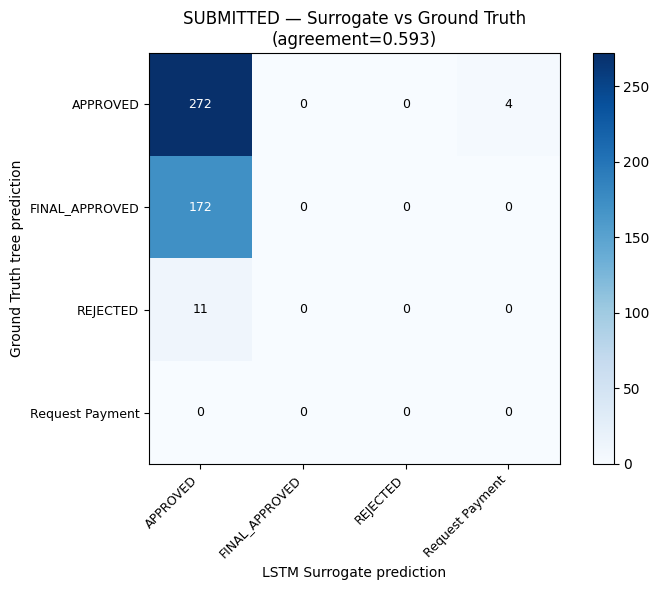

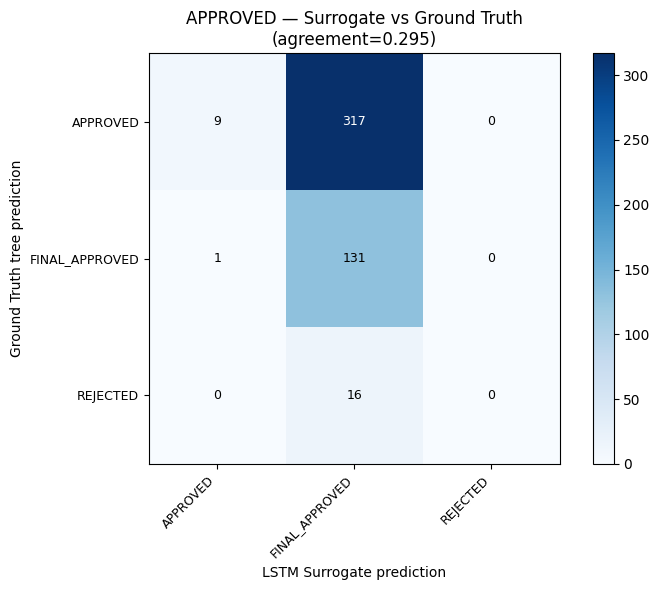

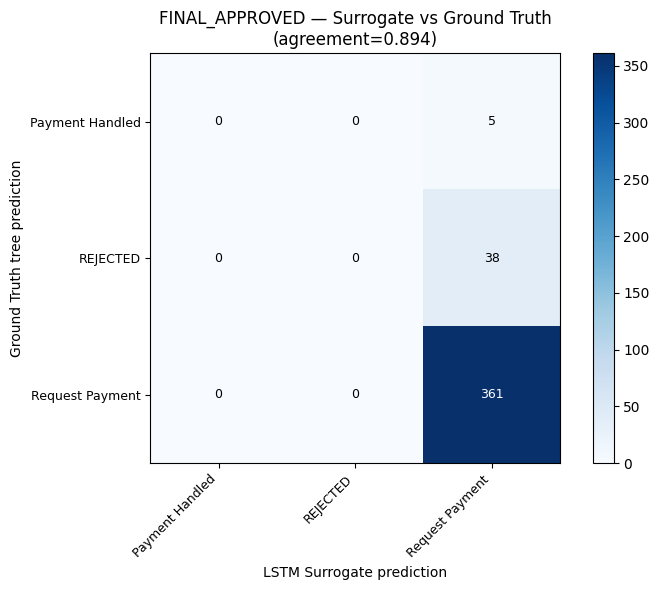

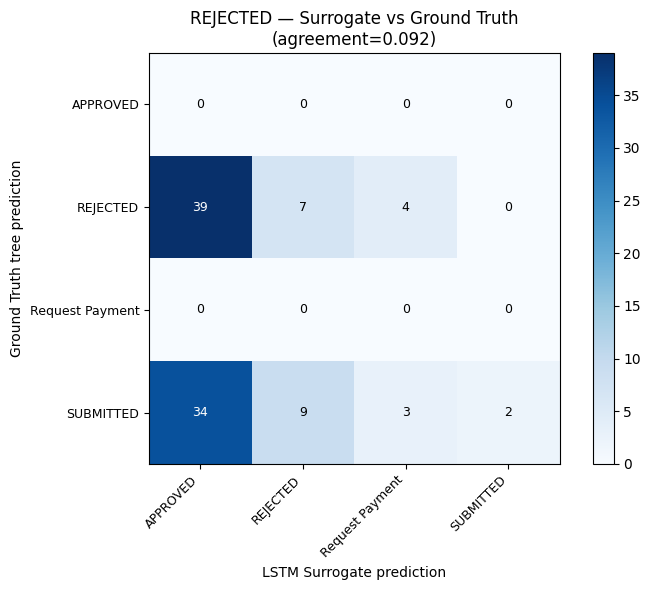

In [22]:
for gateway_act, gr in gateway_results.items():
    y_surr = gr['clf_lstm'].predict(gr['X_test'])
    y_gt = gr['clf_gt'].predict(gr['X_test'])

    labels = sorted(set(y_surr) | set(y_gt))
    cm = confusion_matrix(y_gt, y_surr, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('LSTM Surrogate prediction')
    ax.set_ylabel('Ground Truth tree prediction')
    ax.set_title(f'{gateway_act} — Surrogate vs Ground Truth\n(agreement={gr["agreement"]:.3f})')
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

## Deep dive: disagreement analysis

For the gateway with the lowest agreement rate, examine individual test cases
where the surrogate and ground truth trees predict different branches. Shows
what the LSTM actually predicted vs what happened, and which features are at
play.

In [23]:
def explain_decision_path(clf, sample, feature_names, cat_cols, cat_mappings):
    """Show the decision path for a single sample through the tree."""
    sample_df = sample.to_frame().T
    node_indicator = clf.decision_path(sample_df)
    node_ids = node_indicator.indices
    tree = clf.tree_

    steps = []
    for node_id in node_ids:
        if tree.feature[node_id] != _tree.TREE_UNDEFINED:
            feat_idx = tree.feature[node_id]
            feat_name = feature_names[feat_idx]
            threshold = tree.threshold[node_id]
            value = sample.iloc[feat_idx]
            direction = '<=' if value <= threshold else '>'

            step = f'{feat_name} = {value:.2f} {direction} {threshold:.2f}'

            if feat_name in cat_cols:
                cats = cat_mappings[feat_name]
                if direction == '<=':
                    incl = [c for i, c in enumerate(cats) if i <= threshold]
                else:
                    incl = [c for i, c in enumerate(cats) if i > threshold]
                preview = ', '.join(str(c) for c in incl[:5])
                if len(incl) > 5:
                    preview += f', ... ({len(incl)} total)'
                step += f'  (categories: {preview})'
            steps.append(step)
    return steps


# Find gateway with lowest agreement
worst_gateway = min(gateway_results, key=lambda g: gateway_results[g]['agreement'])
gr = gateway_results[worst_gateway]
print(f'Deepest disagreement: {worst_gateway} (agreement={gr["agreement"]:.3f})\n')

y_surr = gr['clf_lstm'].predict(gr['X_test'])
y_gt_pred = gr['clf_gt'].predict(gr['X_test'])
disagree_mask = y_surr != y_gt_pred
disagree_indices = np.where(disagree_mask)[0]

n_show = min(8, len(disagree_indices))
rng = np.random.RandomState(42)
show_indices = rng.choice(disagree_indices, size=n_show, replace=False)

for idx in show_indices:
    sample = gr['X_test'].iloc[idx]
    lstm_pred = gr['y_lstm_test'][idx]
    actual = gr['y_actual_test'][idx]
    surr_pred = y_surr[idx]
    gt_pred = y_gt_pred[idx]

    print(f'{"=" * 80}')
    print(f'Actual next: {actual} | LSTM predicted: {lstm_pred}')
    print(f'Surrogate tree: {surr_pred} | GT tree: {gt_pred}')
    print(f'prefix_length={sample["prefix_length"]:.0f}')

    print(f'\n  Surrogate path:')
    for i, step in enumerate(explain_decision_path(
            gr['clf_lstm'], sample, gr['feature_names'], gr['cat_cols'], gr['cat_mappings'])):
        print(f'    {i+1}. {step}')
    print(f'    -> {surr_pred}')

    print(f'\n  GT path:')
    for i, step in enumerate(explain_decision_path(
            gr['clf_gt'], sample, gr['feature_names'], gr['cat_cols'], gr['cat_mappings'])):
        print(f'    {i+1}. {step}')
    print(f'    -> {gt_pred}')
    print()

Deepest disagreement: REJECTED (agreement=0.092)

Actual next: REJECTED | LSTM predicted: APPROVED
Surrogate tree: APPROVED | GT tree: REJECTED
prefix_length=2

  Surrogate path:
    1. mean_event_duration = 113590.80 <= 863543.94
    2. last_case_elapsed_time = 115.00 <= 513521.50
    3. n_unique_activities = 2.00 <= 2.50
    -> APPROVED

  GT path:
    1. last_activity_repeated = 1.00 <= 1.50
    2. Role_pos_-3 = 0.00 <= 0.50  (categories: <pad>)
    3. last_seconds_in_day = 54007.00 > 36679.00
    -> REJECTED

Actual next: SUBMITTED | LSTM predicted: APPROVED
Surrogate tree: APPROVED | GT tree: SUBMITTED
prefix_length=3

  Surrogate path:
    1. mean_event_duration = 161419.20 <= 863543.94
    2. last_case_elapsed_time = 257191.00 <= 513521.50
    3. n_unique_activities = 2.00 <= 2.50
    -> APPROVED

  GT path:
    1. last_activity_repeated = 2.00 > 1.50
    -> SUBMITTED

Actual next: SUBMITTED | LSTM predicted: APPROVED
Surrogate tree: APPROVED | GT tree: SUBMITTED
prefix_length=3

## Depth sweep comparison

Shows how fidelity/accuracy evolves with tree depth for both trees at each
gateway. Helps judge the interpretability-accuracy tradeoff.

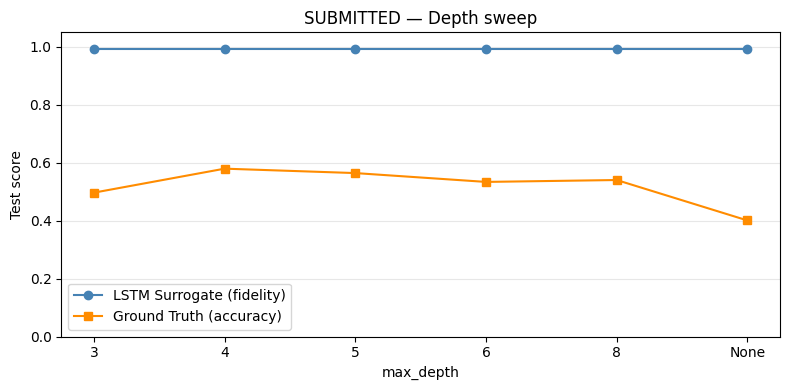

,depth,surr_train,surr_test,surr_leaves,gt_train,gt_test,gt_leaves
0,3,0.990,0.991,2,0.507,0.497,7
1,4,0.990,0.991,2,0.604,0.580,11
2,5,0.990,0.991,2,0.580,0.564,16
3,6,0.990,0.991,2,0.566,0.534,22
4,8,0.990,0.991,2,0.587,0.540,32
5,None,0.990,0.991,2,0.548,0.401,71


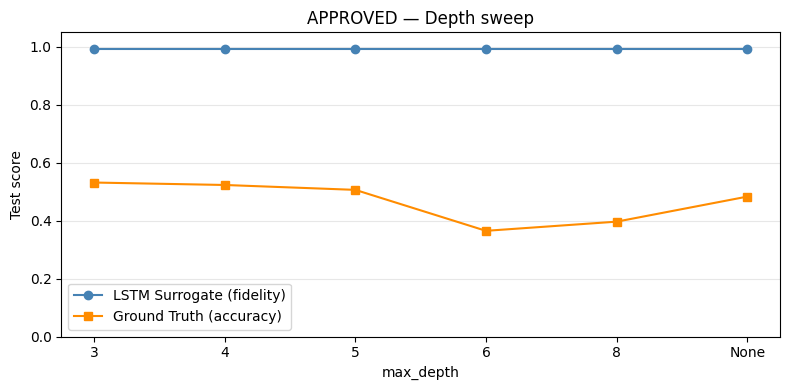

,depth,surr_train,surr_test,surr_leaves,gt_train,gt_test,gt_leaves
0,3,0.995,0.992,3,0.538,0.532,6
1,4,0.995,0.992,3,0.527,0.523,9
2,5,0.995,0.992,3,0.514,0.506,13
3,6,0.995,0.992,3,0.422,0.365,18
4,8,0.995,0.992,3,0.435,0.397,25
5,None,0.995,0.992,3,0.559,0.483,57


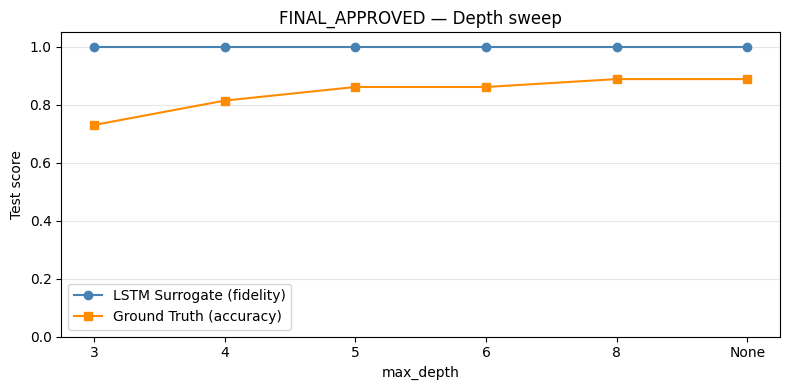

,depth,surr_train,surr_test,surr_leaves,gt_train,gt_test,gt_leaves
0,3,1.000,1.000,1,0.759,0.730,7
1,4,1.000,1.000,1,0.848,0.814,10
2,5,1.000,1.000,1,0.902,0.861,13
3,6,1.000,1.000,1,0.902,0.861,14
4,8,1.000,1.000,1,0.917,0.889,16
5,None,1.000,1.000,1,0.917,0.889,16


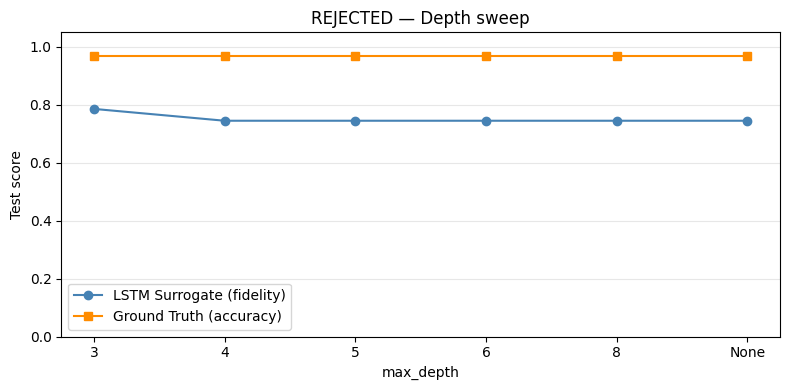

,depth,surr_train,surr_test,surr_leaves,gt_train,gt_test,gt_leaves
0,3,0.770,0.786,5,0.964,0.969,5
1,4,0.701,0.745,8,0.964,0.969,6
2,5,0.701,0.745,10,0.964,0.969,6
3,6,0.701,0.745,10,0.964,0.969,6
4,8,0.701,0.745,10,0.964,0.969,6
5,None,0.701,0.745,10,0.964,0.969,6


In [24]:
for gateway_act, gr in gateway_results.items():
    lstm_sw = gr['lstm_sweep']
    gt_sw = gr['gt_sweep']

    depths_label = [str(r['depth']) if r['depth'] is not None else 'None' for r in lstm_sw]
    lstm_test = [r['test'] for r in lstm_sw]
    gt_test = [r['test'] for r in gt_sw]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(depths_label))
    ax.plot(x, lstm_test, 'o-', color='steelblue', label='LSTM Surrogate (fidelity)')
    ax.plot(x, gt_test, 's-', color='darkorange', label='Ground Truth (accuracy)')
    ax.set_xticks(x)
    ax.set_xticklabels(depths_label)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test score')
    ax.set_title(f'{gateway_act} — Depth sweep')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Table
    rows = []
    for ls, gs in zip(lstm_sw, gt_sw):
        rows.append({
            'depth': ls['depth'] if ls['depth'] is not None else 'None',
            'surr_train': f'{ls["train"]:.3f}',
            'surr_test': f'{ls["test"]:.3f}',
            'surr_leaves': ls['clf'].get_n_leaves(),
            'gt_train': f'{gs["train"]:.3f}',
            'gt_test': f'{gs["test"]:.3f}',
            'gt_leaves': gs['clf'].get_n_leaves(),
        })
    display(pd.DataFrame(rows))